# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview (v5.0)
- **8 agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender
- **Soft agent cycling**: all agents learn every episode (non-active at reduced LR)

## 1. Setup — Clone Repository & Install Dependencies

In [1]:
import os, sys

def _is_project_root(path: str) -> bool:
    """A valid project root has both src/ and configs/ directories."""
    return (os.path.isdir(os.path.join(path, 'src')) and
            os.path.isdir(os.path.join(path, 'configs')))

if not _is_project_root('.'):
    # ── Local: notebook is inside notebooks/ → project root is one level up ──
    _local_candidates = ['..', os.path.join('..', '..')]

    # ── Colab: after git clone the repo lands next to this notebook ──────────
    _colab_candidates = [
        os.path.join('Thesis-Energy-Auction', 'ets_marl_happo_current'),
        os.path.join('Thesis-Energy-Auction', 'ets_marl_legacy_ppo'),
        os.path.join('Thesis-Energy-Auction', 'ets_marl ppo'),
        os.path.join('Thesis-Energy-Auction', 'ets_marl_ppo'),
        'Thesis-Energy-Auction',
    ]

    _found = False
    for _c in _local_candidates + _colab_candidates:
        if _is_project_root(_c):
            os.chdir(_c)
            _found = True
            break

    if not _found:
        # Must be Colab with no clone yet — clone then retry
        os.system('git clone https://github.com/DJH961/Thesis-Energy-Auction.git 2>/dev/null || echo "Repo already cloned"')
        for _c in _colab_candidates:
            if _is_project_root(_c):
                os.chdir(_c)
                _found = True
                break

    # Dynamic fallback: scan Thesis-Energy-Auction/* for any valid root
    if not _found and os.path.isdir('Thesis-Energy-Auction'):
        for _sub in sorted(os.listdir('Thesis-Energy-Auction')):
            _p = os.path.join('Thesis-Energy-Auction', _sub)
            if os.path.isdir(_p) and _is_project_root(_p):
                os.chdir(_p)
                _found = True
                break

    if not _found:
        raise FileNotFoundError(
            f'Cannot find project root (needs src/ + configs/).\n'
            f'CWD: {os.getcwd()}  |  Contents: {os.listdir(".")}'
        )

sys.path.insert(0, '.')
print(f'Working directory: {os.getcwd()}')

Working directory: /content/Thesis-Energy-Auction/ets_marl_happo_current


In [2]:
# Install dependencies
!pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

# Verify GPU availability
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.5 MB/s eta 0:00:00
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/Thesis-Energy-Auction/ets_marl_happo_current
configfile: pyproject.toml
plugins: typeguard-4.5.1, anyio-4.12.1, langsmith-0.7.18
collected 68 items                                                             

tests/test_cap_schedule.py::test_cap_year_0 PASSED                       [  1%]
tests/test_cap_schedule.py::test_cap_year_1_lrf_phase1 PASSED            [  2%]
tests/test_cap_schedule.py::test_cap_year_5_switches_to_phase2 PASSED    [  4%]
tests/test_cap_schedule.py::test_cap_strictly_decreasing PASSED          [  5%]
tests/test_cap_schedule.py::test_cap_year_10 PASSED                      [  7%]
tests/test_cap_schedule.py::test_msr_no_adjustment_within_band PASSED    [  8%]
tests/test_cap_schedule.py::test_msr_withhold_when_tnac_high PASSED      [ 10%]
tests/test_cap_schedule.py

## 3. Explore the Environment

In [4]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {TECH_NAMES}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

tech_names = config['technologies']['names']
for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(5)])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M€/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')

=== Environment Summary ===
Agents: 8
Years: 20
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 57
Initial cap: 23.50 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A3: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A4: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A5: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt | Green: 70% | Op. Cost: 342 M€/yr | Avg EF: 0.177 tCO2/MWh
A6: coal: 5% | gas: 25% | o

## 4. Run a Random-Policy Episode (Baseline)

In [5]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config['auction']
inv = config['investment']

year_data = []

for year in range(config['simulation']['n_years']):
    # Random auction actions (use config bounds)
    auction_actions = rng.uniform(
        [aq['price_min'], 0.0, 0.0, -1.0, -1.0, -1.0],
        [aq['price_max'], aq['quantity_max'], inv['max_invest_frac'], 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)

    obs2, _ = env.step_auction(auction_actions)

    # Random secondary actions
    secondary_actions = rng.uniform(
        [0.5, -aq['quantity_max']], [2.0, aq['quantity_max']], size=(n_agents, 2)
    ).astype(np.float32)

    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'reward_A{i+1}'] = rewards[i]
    year_data.append(row)

    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[['year', 'cap', 'price']].to_string(index=False))

 year       cap      price
    0 23.500000 381.764160
    1 22.489500 150.328903
    2 21.522451 169.126648
    3 20.596986 186.991928
    4 19.690719 158.615662
    5 18.824327 403.173950
    6 17.996057 199.675079
    7 17.204230 203.057251
    8 16.447244 264.918701
    9 15.723565 241.365402
   10 15.031728 297.208527
   11 14.370332 497.377380
   12 13.738038 276.253693
   13 13.133564 361.059692
   14 12.555687 448.580444
   15 12.003237 313.240814
   16 11.475095 329.481293
   17 10.970190 295.050873
   18 10.487502 250.072800
   19 10.026052 233.227997


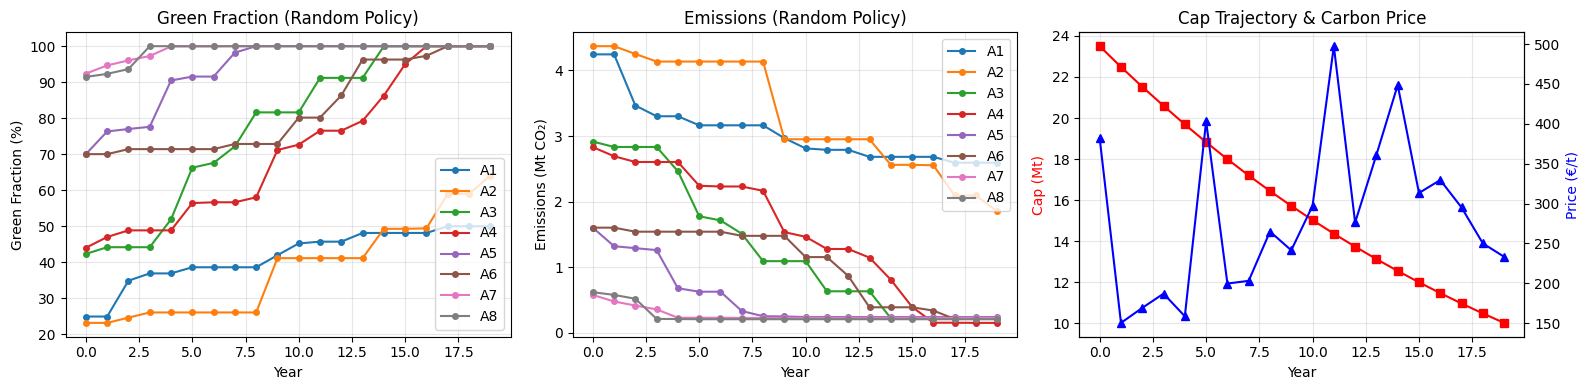

In [6]:
# Plot: Green fraction evolution (random policy)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Green fracs
ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions
ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt CO₂)')
ax.set_title('Emissions (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cap & Price
ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (€/t)', marker='^', color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (€/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train PPO Agents (Short Run)

In [7]:
from scripts.train import train_one_seed

# Override for quick Colab run (reduce episodes)
train_config = config.copy()
train_config['simulation'] = dict(config['simulation'])
train_config['simulation']['n_episodes'] = 1500  # Increase for better results
train_config['logging'] = dict(config['logging'])
train_config['logging']['log_interval'] = 49
train_config['logging']['save_interval'] = 100

train_one_seed(train_config, seed=42)


Training — seed 42, 8 agents, HAPPO (sequential update, centralized critic), two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward | CF-cap=0.5×
Clipped Gaussian (no tanh) + P1-P8 active | Curriculum 4→20yr | ε-greedy 25%→5%

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    :

## 6. Analyze Training Results

In [8]:
# Load training logs
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')

print(f'Training episodes: {len(ep_df)}')
print(f'Year-level records: {len(yr_df)}')
ep_df.tail()

Training episodes: 1500
Year-level records: 11996


,episode,clearing_price_last,cap_last,entropy_coef,shaping_weight,entropy_decay_triggered,active_agent,epsilon,reward_A1,green_frac_A1,...,total_cancels_A7,total_holding_cost_A7,total_mac_reduction_A7,mean_alloc_A8,mean_shock_A8,max_shock_A8,mean_cf_shock_A8,total_cancels_A8,total_holding_cost_A8,total_mac_reduction_A8
1495,1495,134.402893,14.370332,0.03,0.8754,1,-1,0.2073,-30.8228,0.2954,...,0,0.0,0.0,0.1855,0.0,0.0,0.0,0,0.0,0.0
1496,1496,91.518768,14.370332,0.03,0.8753,1,-1,0.2073,-38.2964,0.3661,...,0,0.0,0.0,0.1700,0.0,0.0,0.0,0,0.0,0.0
1497,1497,160.182266,14.370332,0.03,0.8752,1,-1,0.2072,-40.6188,0.2700,...,0,0.0,0.0,0.2751,0.0,0.0,0.0,0,0.0,0.0
1498,1498,132.309402,14.370332,0.03,0.8752,1,-1,0.2072,-38.6293,0.2236,...,0,0.0,0.0,0.2208,0.0,0.0,0.0,0,0.0,0.0
1499,1499,52.687284,14.370332,0.03,0.8751,1,-1,0.2072,-25.2086,0.3440,...,0,0.0,0.0,0.2314,0.0,0.0,0.0,0,0.0,0.0


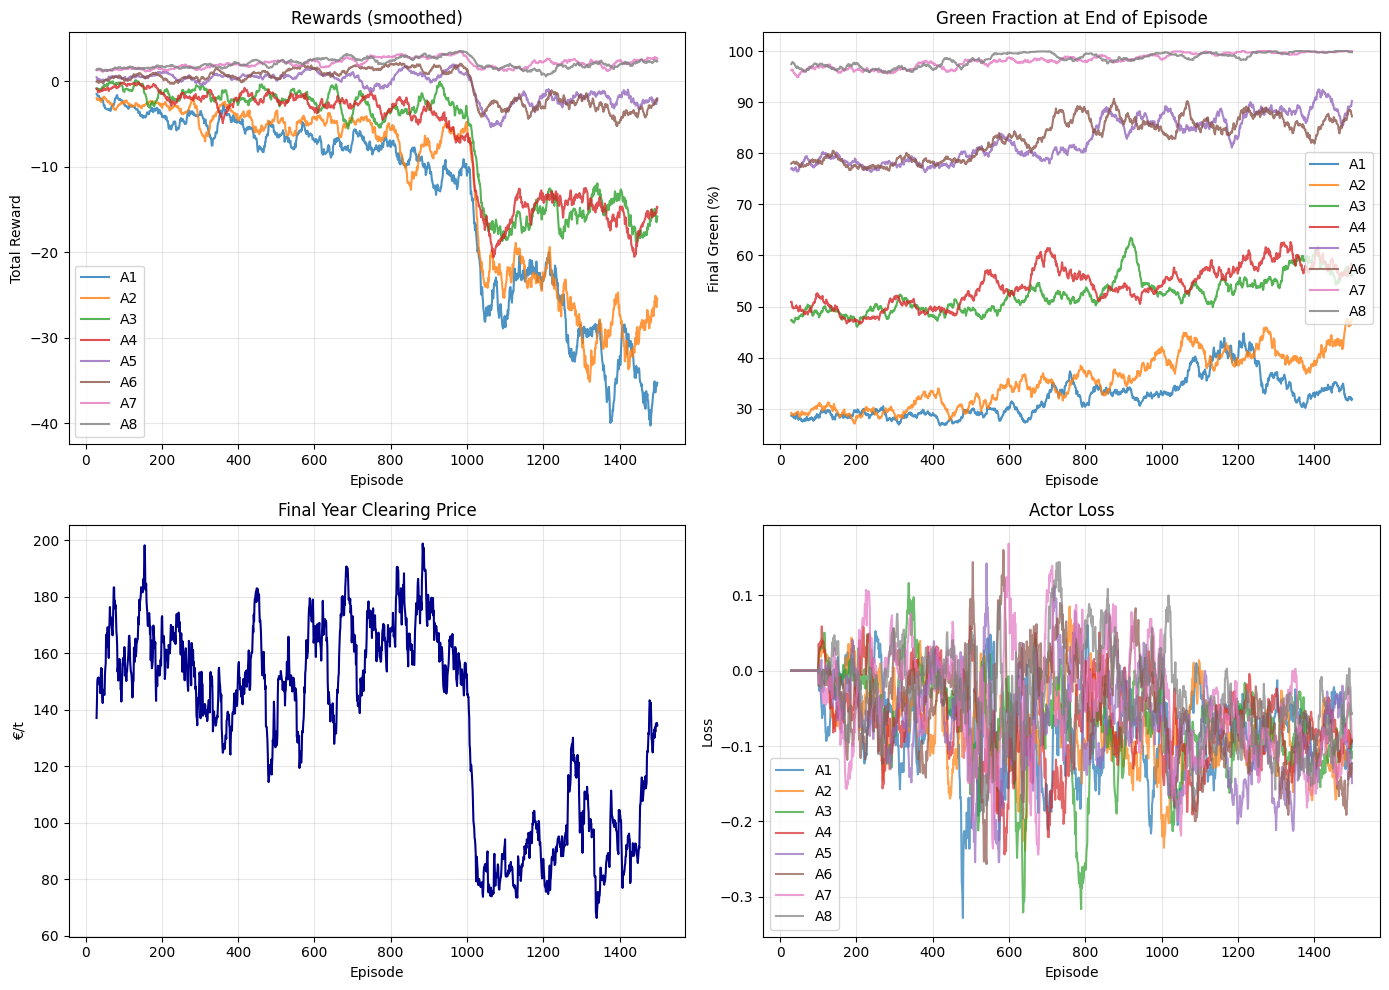

In [9]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_agents = config['companies']['n_agents']
window = max(1, len(ep_df) // 50)  # smoothing window

# 1. Rewards
ax = axes[0, 0]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Rewards (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Green fractions
ax = axes[0, 1]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean() * 100, label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Final Green (%)')
ax.set_title('Green Fraction at End of Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Clearing price
ax = axes[1, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(window).mean(), color='darkblue')
ax.set_xlabel('Episode')
ax.set_ylabel('€/t')
ax.set_title('Final Year Clearing Price')
ax.grid(True, alpha=0.3)

# 4. Actor loss
ax = axes[1, 1]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Actor Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

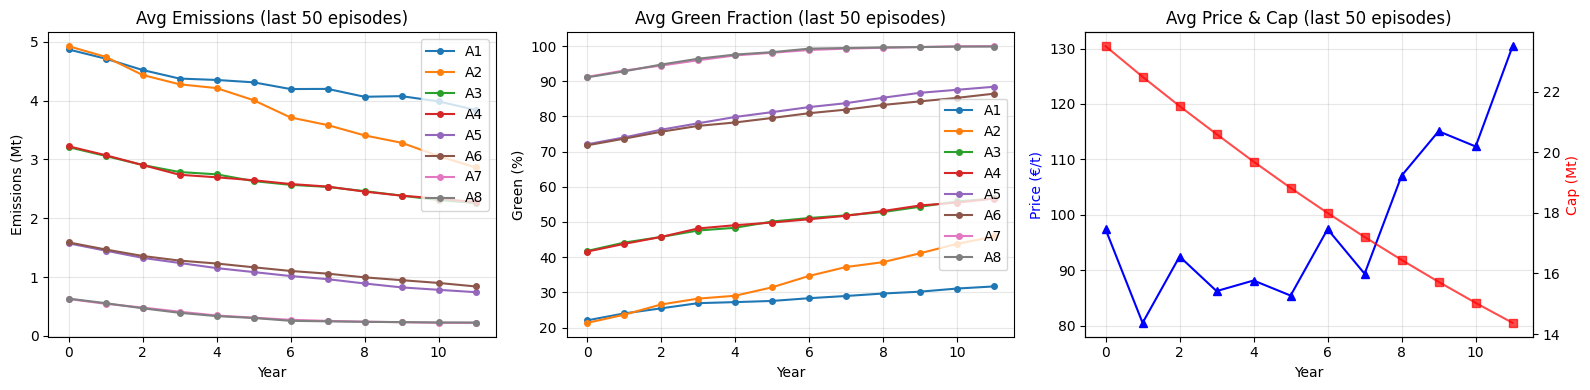

In [10]:
# Year-level analysis: last 50 episodes
last_eps = yr_df['episode'].unique()[-50:]
recent = yr_df[yr_df['episode'].isin(last_eps)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Emissions by year (averaged over recent episodes)
ax = axes[0]
for i in range(n_agents):
    avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(avg.index, avg.values, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt)')
ax.set_title('Avg Emissions (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Green frac by year
ax = axes[1]
for i in range(n_agents):
    avg = recent.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(avg.index, avg.values * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green (%)')
ax.set_title('Avg Green Fraction (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Carbon price trajectory
ax = axes[2]
avg_price = recent.groupby('year')['clearing_price'].mean()
avg_cap = recent.groupby('year')['cap'].mean()
ax.plot(avg_price.index, avg_price.values, label='Clearing Price', marker='^', color='blue')
ax2 = ax.twinx()
ax2.plot(avg_cap.index, avg_cap.values, label='Cap', marker='s', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Price (€/t)', color='blue')
ax2.set_ylabel('Cap (Mt)', color='red')
ax.set_title('Avg Price & Cap (last 50 episodes)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6b. P5–P8 & MAC Stochastic Deviation Analysis

Visualise the **random noise** and **abatement mechanisms** across training:
- **P5** — Emission demand shocks (ε ~ correlated normal, σ=7%)
- **P6** — Green capacity-factor noise + project cancellations
- **P8** — Banking holding costs (penalty for excess allowance hoarding)
- **MAC** — Fuel-switching abatement (coal→gas dispatch when carbon price > €65/t)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


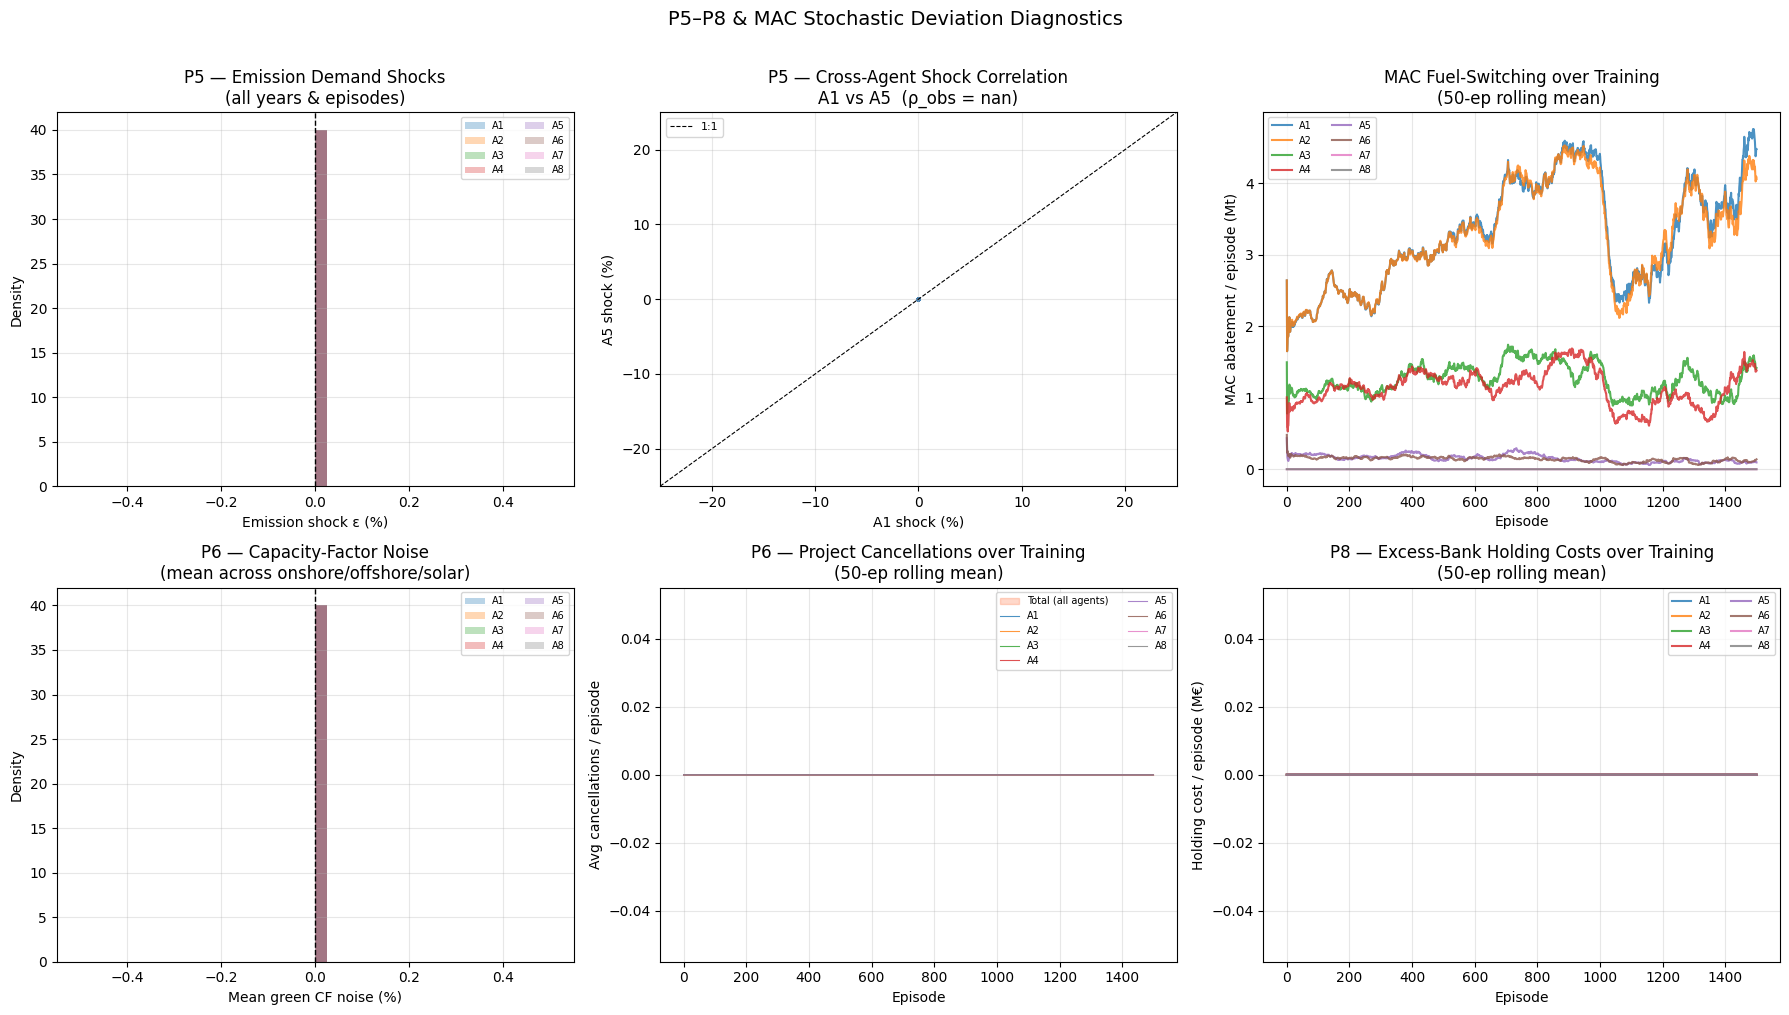


─── P5/P6/P8/MAC deviation summary (all training data) ───
    ε_mean (%)  ε_std (%)  CF_noise_std (%)  cancels_total  holdcost_sum (M€)  mac_total (Mt)
A1         0.0        0.0               0.0            0.0                0.0         4966.38
A2         0.0        0.0               0.0            0.0                0.0         4899.18
A3         0.0        0.0               0.0            0.0                0.0         1892.54
A4         0.0        0.0               0.0            0.0                0.0         1730.62
A5         0.0        0.0               0.0            0.0                0.0          223.93
A6         0.0        0.0               0.0            0.0                0.0          211.82
A7         0.0        0.0               0.0            0.0                0.0            0.00
A8         0.0        0.0               0.0            0.0                0.0            0.00


In [11]:
# ── P5/P6/P8 stochastic deviation analysis ─────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

# Check which deviation columns exist
shock_cols    = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols       = [f'cf_shock_A{i+1}'       for i in range(n_agents)]
cancel_cols   = [f'cancellation_A{i+1}'   for i in range(n_agents)]
hcost_cols    = [f'holding_cost_A{i+1}'   for i in range(n_agents)]
mac_cols      = [f'mac_reduction_A{i+1}'  for i in range(n_agents)]

has_deviations = all(c in yr_df.columns for c in shock_cols)
has_mac = all(c in yr_df.columns for c in mac_cols)

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i % 10) for i in range(n_agents)]
leg_ncol = max(1, n_agents // 4)
bar_alpha = max(0.25, 0.55 - n_agents * 0.03)  # reduce opacity with more agents

if not has_deviations:
    print('Deviation columns not found — re-run training with the updated train.py')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # ── 1. P5 emission shock distribution (all agents, all years) ────────────
    ax = axes[0, 0]
    for i in range(n_agents):
        vals = yr_df[shock_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}',
                density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Emission shock ε (%)')
    ax.set_ylabel('Density')
    ax.set_title('P5 — Emission Demand Shocks\n(all years & episodes)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 2. P5 shock correlation check (A1 vs A(n//2) — spread archetypes) ────
    ax = axes[0, 1]
    idx_a, idx_b = 0, max(1, n_agents // 2)
    ax.scatter(yr_df[shock_cols[idx_a]] * 100, yr_df[shock_cols[idx_b]] * 100,
               alpha=0.15, s=4, color='steelblue')
    lims = [-25, 25]
    ax.plot(lims, lims, 'k--', lw=0.8, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'A{idx_a+1} shock (%)')
    ax.set_ylabel(f'A{idx_b+1} shock (%)')
    corr = yr_df[shock_cols[idx_a]].corr(yr_df[shock_cols[idx_b]])
    ax.set_title(f'P5 — Cross-Agent Shock Correlation\nA{idx_a+1} vs A{idx_b+1}  (ρ_obs = {corr:.2f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 3. MAC fuel-switching over training ──────────────────────────────────
    ax = axes[0, 2]
    if has_mac:
        ep_mac = (
            yr_df.groupby('episode')[[*mac_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_mac.index, ep_mac[mac_cols[i]],
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.set_xlabel('Episode')
        ax.set_ylabel('MAC abatement / episode (Mt)')
        ax.set_title('MAC Fuel-Switching over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=7, ncol=leg_ncol)
    else:
        # Fallback: P5 shock volatility
        ep_shock_std = (
            yr_df.groupby('episode')[[*shock_cols]]
            .std()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_shock_std.index, ep_shock_std[shock_cols[i]] * 100,
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.axhline(7.0, color='k', ls='--', lw=0.8, label='σ_demand=7%')
        ax.set_xlabel('Episode')
        ax.set_ylabel('Within-episode shock std (%)')
        ax.set_title('P5 — Emission Shock Volatility over Training')
        ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 4. P6 CF noise distribution (green techs averaged) ───────────────────
    ax = axes[1, 0]
    for i in range(n_agents):
        vals = yr_df[cf_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=bar_alpha, label=f'A{i+1}',
                density=True, color=agent_colors[i])
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Mean green CF noise (%)')
    ax.set_ylabel('Density')
    ax.set_title('P6 — Capacity-Factor Noise\n(mean across onshore/offshore/solar)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 5. P6 project cancellations over training ─────────────────────────────
    ax = axes[1, 1]
    ep_cancels = (
        yr_df.groupby('episode')[[*cancel_cols]]
        .sum()
        .rolling(50, min_periods=1)
        .mean()
    )
    ep_cancels['total'] = ep_cancels[cancel_cols].sum(axis=1)
    ax.fill_between(ep_cancels.index, ep_cancels['total'],
                    alpha=0.3, color='coral', label='Total (all agents)')
    for i in range(n_agents):
        ax.plot(ep_cancels.index, ep_cancels[cancel_cols[i]],
                lw=0.8, label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg cancellations / episode')
    ax.set_title('P6 — Project Cancellations over Training\n(50-ep rolling mean)')
    ax.legend(fontsize=7, ncol=leg_ncol)
    ax.grid(True, alpha=0.3)

    # ── 6. P8 holding cost over training ─────────────────────────────────────
    ax = axes[1, 2]
    has_hcost = all(c in yr_df.columns for c in hcost_cols)
    if has_hcost:
        ep_hcost = (
            yr_df.groupby('episode')[[*hcost_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_hcost.index, ep_hcost[hcost_cols[i]],
                    label=f'A{i+1}', alpha=0.8, color=agent_colors[i])
        ax.set_xlabel('Episode')
        ax.set_ylabel('Holding cost / episode (M€)')
        ax.set_title('P8 — Excess-Bank Holding Costs over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=7, ncol=leg_ncol)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'holding_cost columns\nnot found in CSV',
                ha='center', va='center', transform=ax.transAxes)

    plt.suptitle('P5–P8 & MAC Stochastic Deviation Diagnostics', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary statistics table
    print('\n─── P5/P6/P8/MAC deviation summary (all training data) ───')
    summary = {}
    for i in range(n_agents):
        row = {
            'ε_mean (%)':       round(yr_df[shock_cols[i]].mean()  * 100, 3),
            'ε_std (%)':        round(yr_df[shock_cols[i]].std()   * 100, 3),
            'CF_noise_std (%)': round(yr_df[cf_cols[i]].std()      * 100, 3),
            'cancels_total':    int(yr_df[cancel_cols[i]].sum()),
            'holdcost_sum (M€)': round(yr_df[hcost_cols[i]].sum(), 2) if has_hcost else 'n/a',
        }
        if has_mac:
            row['mac_total (Mt)'] = round(yr_df[mac_cols[i]].sum(), 2)
        summary[f'A{i+1}'] = row
    print(pd.DataFrame(summary).T.to_string())


## 6c. Year-by-Year Trajectory Analysis (last N episodes)

Slices the **year_log** to show how behaviour evolves *within* an episode across years 0–9.
Uses the last 100 episodes so the plots represent mature policy behaviour, not early exploration.

Four panels per row:
1. **Allocation vs Emissions** — over-allocation → surplus banking; under-allocation → shortfall risk  
2. **Banking** — bank_start and bank_end per year to see carry-forward dynamics  
3. **Secondary market net** — positive = net seller (revenue), negative = net buyer (cost)  
4. **Compliance surplus / shortfall** — pre-compliance headroom; negative → penalty risk

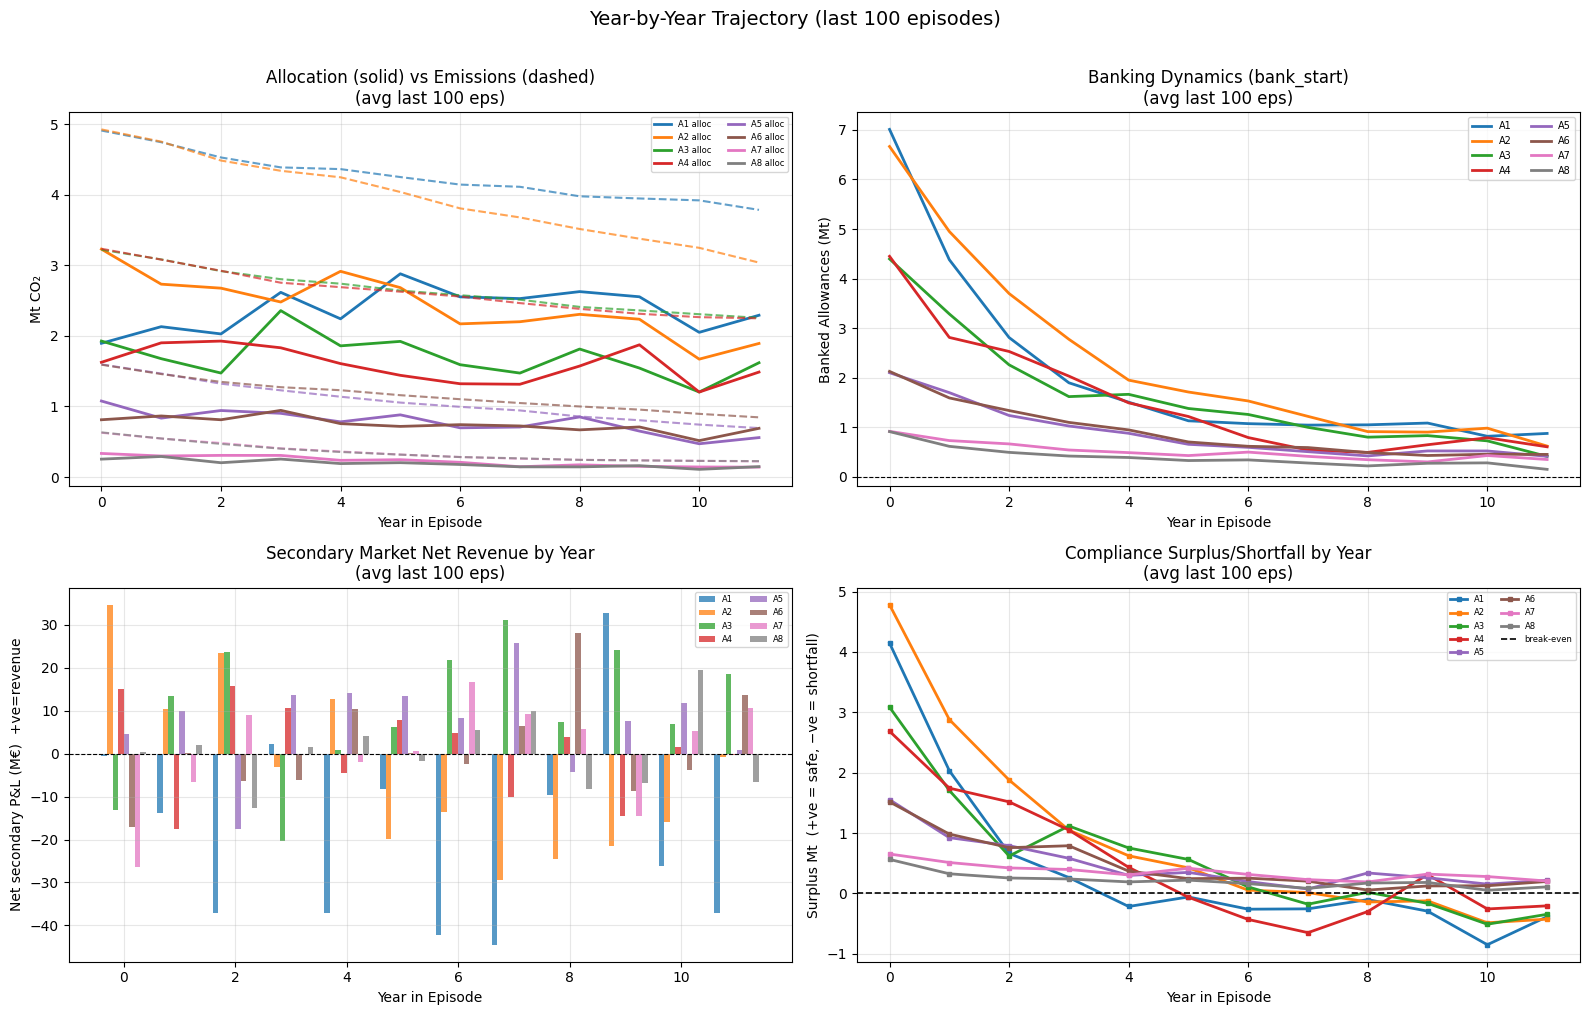


── Average yearly cost breakdown (last 100 eps, all agents combined) ──
      A1_auc(M€)  A1_inv(M€)  A1_pen(M€)  A2_auc(M€)  A2_inv(M€)  A2_pen(M€)  A3_auc(M€)  A3_inv(M€)  A3_pen(M€)  A4_auc(M€)  A4_inv(M€)  A4_pen(M€)  A5_auc(M€)  A5_inv(M€)  A5_pen(M€)  A6_auc(M€)  A6_inv(M€)  A6_pen(M€)  A7_auc(M€)  A7_inv(M€)  A7_pen(M€)  A8_auc(M€)  A8_inv(M€)  A8_pen(M€)
year                                                                                                                                                                                                                                                                                                
0         268.16       90.76       23.23      472.33      313.42       16.77      205.73      181.42       19.91      191.52      205.42       12.33      113.26      119.58       14.25       93.60      102.25        7.22       32.65      135.07        7.48       26.13      107.51        4.77
1         224.39       88.45      100.68      27

In [12]:
# ── 6c: Year-by-year trajectory analysis ──────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100  # episodes to average over
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()

# Check which new columns are present
has_bank_end   = 'bank_end_A1'            in recent.columns
has_sec_net    = 'secondary_net_A1'       in recent.columns
has_surplus    = 'compliance_surplus_A1'  in recent.columns
has_auc_cost   = 'auction_cost_A1'        in recent.columns

cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Panel 1: Allocation vs Emissions ──────────────────────────────────────
ax = axes[0, 0]
for i in range(n_agents):
    alloc_avg = recent.groupby('year')[f'alloc_A{i+1}'].mean()
    emiss_avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(alloc_avg.index, alloc_avg.values,
            color=agent_colors[i], lw=2, label=f'A{i+1} alloc')
    ax.plot(emiss_avg.index, emiss_avg.values,
            color=agent_colors[i], lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Mt CO₂')
ax.set_title(f'Allocation (solid) vs Emissions (dashed)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 2: Banking dynamics (bank_start and bank_end) ────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    bs = recent.groupby('year')[f'bank_start_A{i+1}'].mean()
    ax.plot(bs.index, bs.values, color=agent_colors[i], lw=2,
            label=f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Banked Allowances (Mt)')
ax.set_title(f'Banking Dynamics (bank_start)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 3: Secondary market net (positive = net revenue) ────────────────
ax = axes[1, 0]
if has_sec_net:
    bar_width = 0.8 / n_agents
    for i in range(n_agents):
        avg = recent.groupby('year')[f'secondary_net_A{i+1}'].mean()
        ax.bar(avg.index + i * bar_width - 0.4 + bar_width/2, avg.values,
               width=bar_width, color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('Net secondary P&L (M€)  +ve=revenue')
    ax.set_title(f'Secondary Market Net Revenue by Year\n(avg last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
else:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'trade_cost_A{i+1}'].mean()
        ax.plot(avg.index, -avg.values, color=agent_colors[i], lw=1.5,
                label=f'A{i+1}', marker='o', markersize=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('−trade_cost (M€)  +ve=revenue')
    ax.set_title(f'Secondary Net (from trade_cost, last {N_LAST} eps)')
    ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 4: Compliance surplus / shortfall ───────────────────────────────
ax = axes[1, 1]
if has_surplus:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'compliance_surplus_A{i+1}'].mean()
        ax.plot(avg.index, avg.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--', label='break-even')
else:
    for i in range(n_agents):
        sf = recent.groupby('year')[f'shortfall_A{i+1}'].mean()
        ax.plot(sf.index, -sf.values, color=agent_colors[i], lw=2,
                marker='s', markersize=3, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Surplus Mt  (+ve = safe, −ve = shortfall)')
ax.set_title(f'Compliance Surplus/Shortfall by Year\n(avg last {N_LAST} eps)')
ax.legend(fontsize=6, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Year-by-Year Trajectory (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Cost breakdown summary per year (if auction_cost logged) ──────────────
if has_auc_cost:
    print(f'\n── Average yearly cost breakdown (last {N_LAST} eps, all agents combined) ──')
    cols_show = {}
    for i in range(n_agents):
        cols_show[f'A{i+1}_auc(M€)'] = recent.groupby('year')[f'auction_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_inv(M€)'] = recent.groupby('year')[f'invest_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_pen(M€)'] = recent.groupby('year')[f'penalty_A{i+1}'].mean()
    print(pd.DataFrame(cols_show).round(2).to_string())


## 6d. Episode Consistency & Variance (ribbon plots)

Shows **mean ± 1 std** bands over the last 100 episodes for key year-level signals.
Wide bands → high variance / unstable policy. Narrow bands → consistent behaviour.

Includes a **price ribbon** (year 0→9 trajectory) and per-agent **green fraction trajectory**.

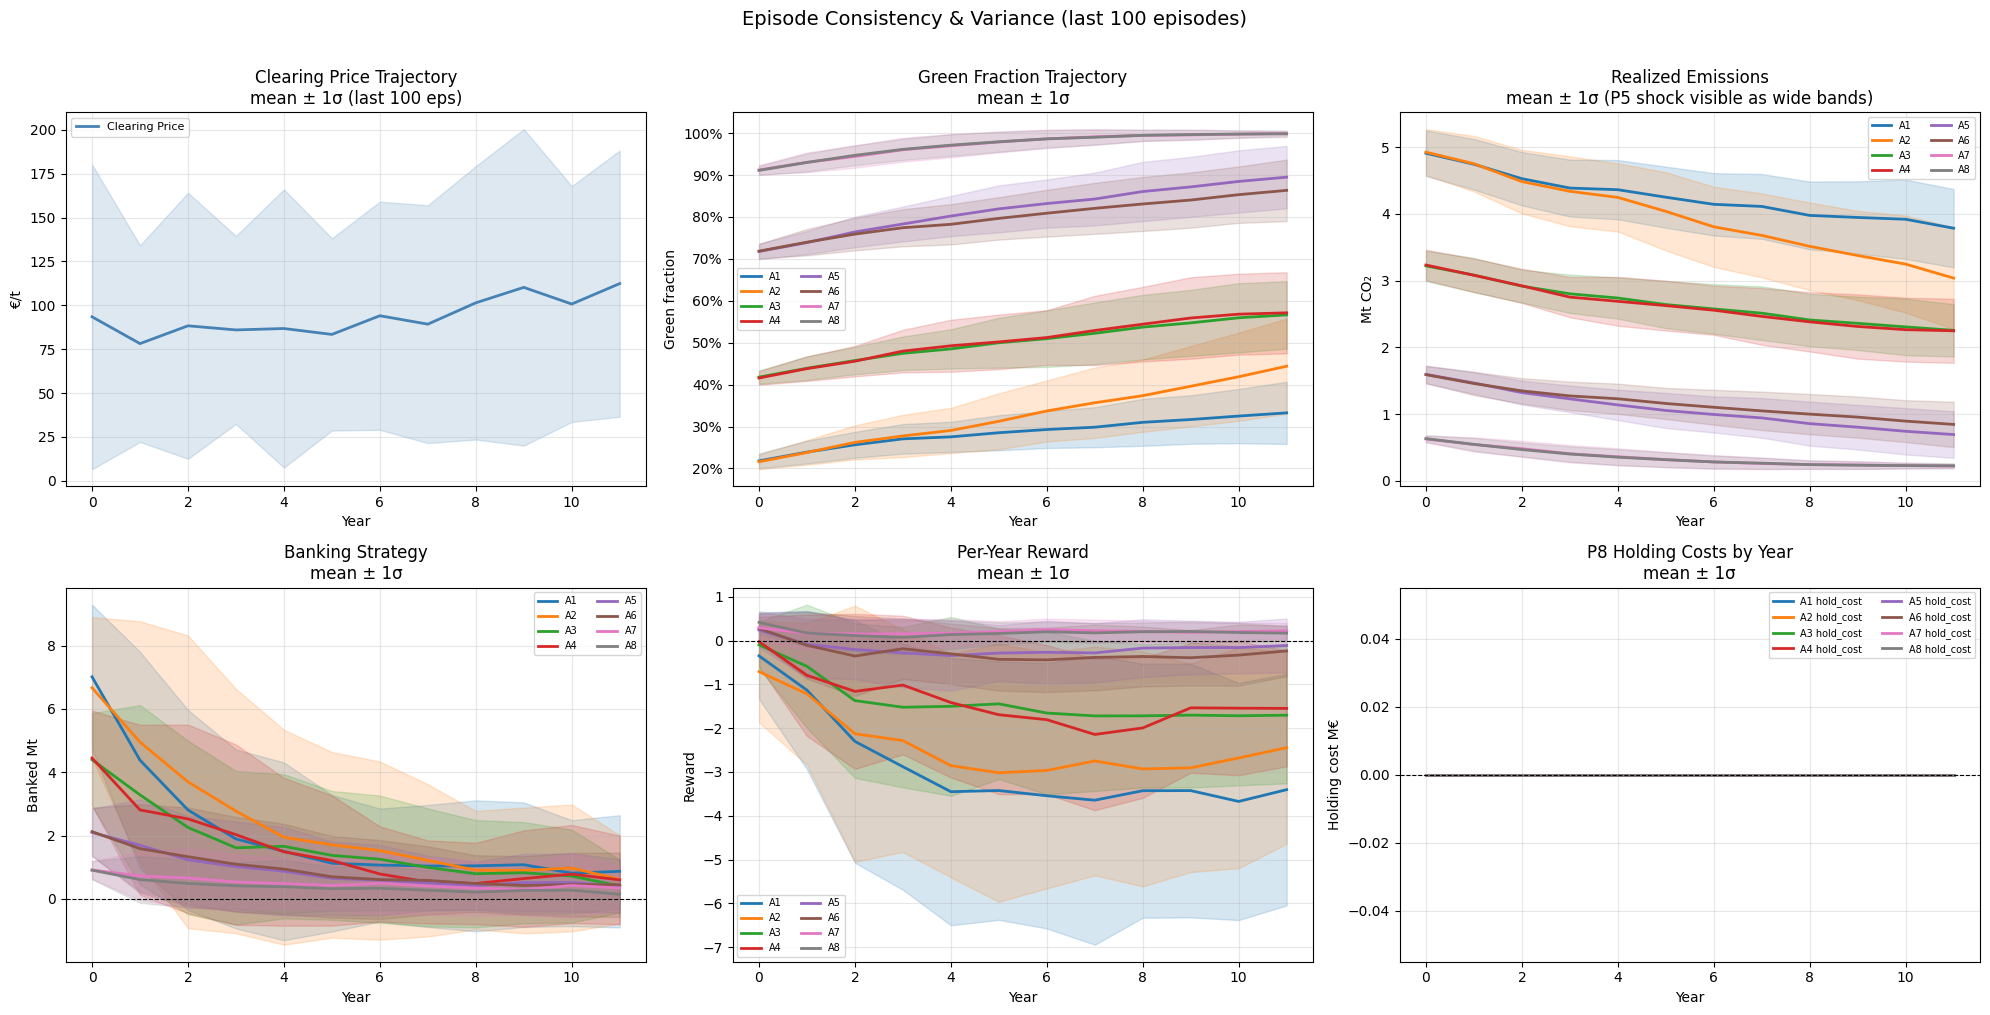


── Year-level variance summary (std across 100 episodes, mean over years) ──
    price_std (€/t)  green_frac_std  emissions_std(Mt)  bank_std(Mt)  reward_std
A1            70.83          0.0445              0.469         2.320      2.6541
A2            70.83          0.0680              0.575         2.776      2.4010
A3            70.83          0.0569              0.338         1.936      1.6083
A4            70.83          0.0656              0.371         1.914      1.5160
A5            70.83          0.0533              0.258         1.080      0.6613
A6            70.83          0.0516              0.248         1.174      0.6811
A7            70.83          0.0186              0.086         0.804      0.2716
A8            70.83          0.0176              0.081         0.657      0.2654


In [13]:
# ── 6d: Episode consistency – ribbon plots (mean ± 1σ over last 100 episodes) ──
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()
years  = sorted(recent['year'].unique())

def ribbon(ax, grp, col, color, label):
    """Plot mean ± 1 std ribbon for `col` grouped by year."""
    mu  = grp[col].mean()
    std = grp[col].std().fillna(0)
    ax.plot(mu.index, mu.values, color=color, lw=2, label=label)
    ax.fill_between(mu.index, mu - std, mu + std,
                    color=color, alpha=0.18)

grp = recent.groupby('year')
# Use a colormap that handles 8+ agents
cmap = plt.get_cmap('tab10')
agent_colors = [cmap(i) for i in range(n_agents)]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ── 1. Clearing price trajectory ──────────────────────────────────────────
ax = axes[0, 0]
ribbon(ax, grp, 'clearing_price', 'steelblue', 'Clearing Price')
ax.set_xlabel('Year'); ax.set_ylabel('€/t')
ax.set_title('Clearing Price Trajectory\nmean ± 1σ (last 100 eps)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 2. Green fraction per agent ───────────────────────────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'green_frac_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green fraction')
ax.set_title('Green Fraction Trajectory\nmean ± 1σ')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 3. Emissions per agent ────────────────────────────────────────────────
ax = axes[0, 2]
for i in range(n_agents):
    ribbon(ax, grp, f'emissions_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂')
ax.set_title('Realized Emissions\nmean ± 1σ (P5 shock visible as wide bands)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 4. Banking (bank_start) per agent ─────────────────────────────────────
ax = axes[1, 0]
for i in range(n_agents):
    ribbon(ax, grp, f'bank_start_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Banked Mt')
ax.set_title('Banking Strategy\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 5. Reward per agent ───────────────────────────────────────────────────
ax = axes[1, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'reward_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Reward')
ax.set_title('Per-Year Reward\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

# ── 6. P8 holding cost (if logged) / shortfall ────────────────────────────
ax = axes[1, 2]
has_hcost = 'holding_cost_A1' in recent.columns
if has_hcost:
    for i in range(n_agents):
        ribbon(ax, grp, f'holding_cost_A{i+1}', agent_colors[i], f'A{i+1} hold_cost')
    ax.set_ylabel('Holding cost M€')
    ax.set_title('P8 Holding Costs by Year\nmean ± 1σ')
else:
    for i in range(n_agents):
        ribbon(ax, grp, f'shortfall_A{i+1}', agent_colors[i], f'A{i+1}')
    ax.set_ylabel('Shortfall Mt')
    ax.set_title('Shortfall by Year\nmean ± 1σ')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=2)

plt.suptitle(f'Episode Consistency & Variance (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Variance summary table ────────────────────────────────────────────────
print(f'\n── Year-level variance summary (std across {N_LAST} episodes, mean over years) ──')
var_summary = {}
for i in range(n_agents):
    var_summary[f'A{i+1}'] = {
        'price_std (€/t)':   round(recent.groupby('year')['clearing_price'].std().mean(), 2),
        'green_frac_std':    round(recent.groupby('year')[f'green_frac_A{i+1}'].std().mean(), 4),
        'emissions_std(Mt)': round(recent.groupby('year')[f'emissions_A{i+1}'].std().mean(), 3),
        'bank_std(Mt)':      round(recent.groupby('year')[f'bank_start_A{i+1}'].std().mean(), 3),
        'reward_std':        round(recent.groupby('year')[f'reward_A{i+1}'].std().mean(), 4),
    }
print(pd.DataFrame(var_summary).T.to_string())


## 7. Evaluate Best Agents (Deterministic)

In [14]:
from scripts.train import build_agents

# Load best checkpoints
eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i} — using untrained policy')

# Run deterministic evaluation
obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
green_cols = ['year', 'cap', 'price'] + [f'green_A{i+1}' for i in range(n_agents)]
print(eval_df[green_cols].to_string(index=False))

Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
Loaded agent 4
Loaded agent 5
Loaded agent 6
Loaded agent 7
 year       cap      price  green_A1  green_A2  green_A3  green_A4  green_A5  green_A6  green_A7  green_A8
    0 23.500000  44.043743  0.225409  0.222264  0.437506  0.439117  0.700000  0.718440  0.900000  0.900000
    1 22.489500  41.107494  0.225409  0.229749  0.437506  0.439117  0.706040  0.718440  0.917404  0.900000
    2 21.522451  41.191068  0.284746  0.229749  0.437506  0.439117  0.725303  0.749830  0.929845  0.925376
    3 20.596986 105.785339  0.284746  0.262284  0.481162  0.495641  0.732380  0.761988  0.929845  0.950000
    4 19.690719  63.577850  0.309235  0.262284  0.493940  0.495641  0.732380  0.770628  0.950000  0.950000
    5 18.824327  56.147802  0.309235  0.288920  0.502840  0.495641  0.732380  0.780890  0.950000  0.950000
    6 17.996057  60.136265  0.309235  0.288920  0.535795  0.495641  0.732380  0.781012  0.950000  0.950000
    7 17.204230  47.9631

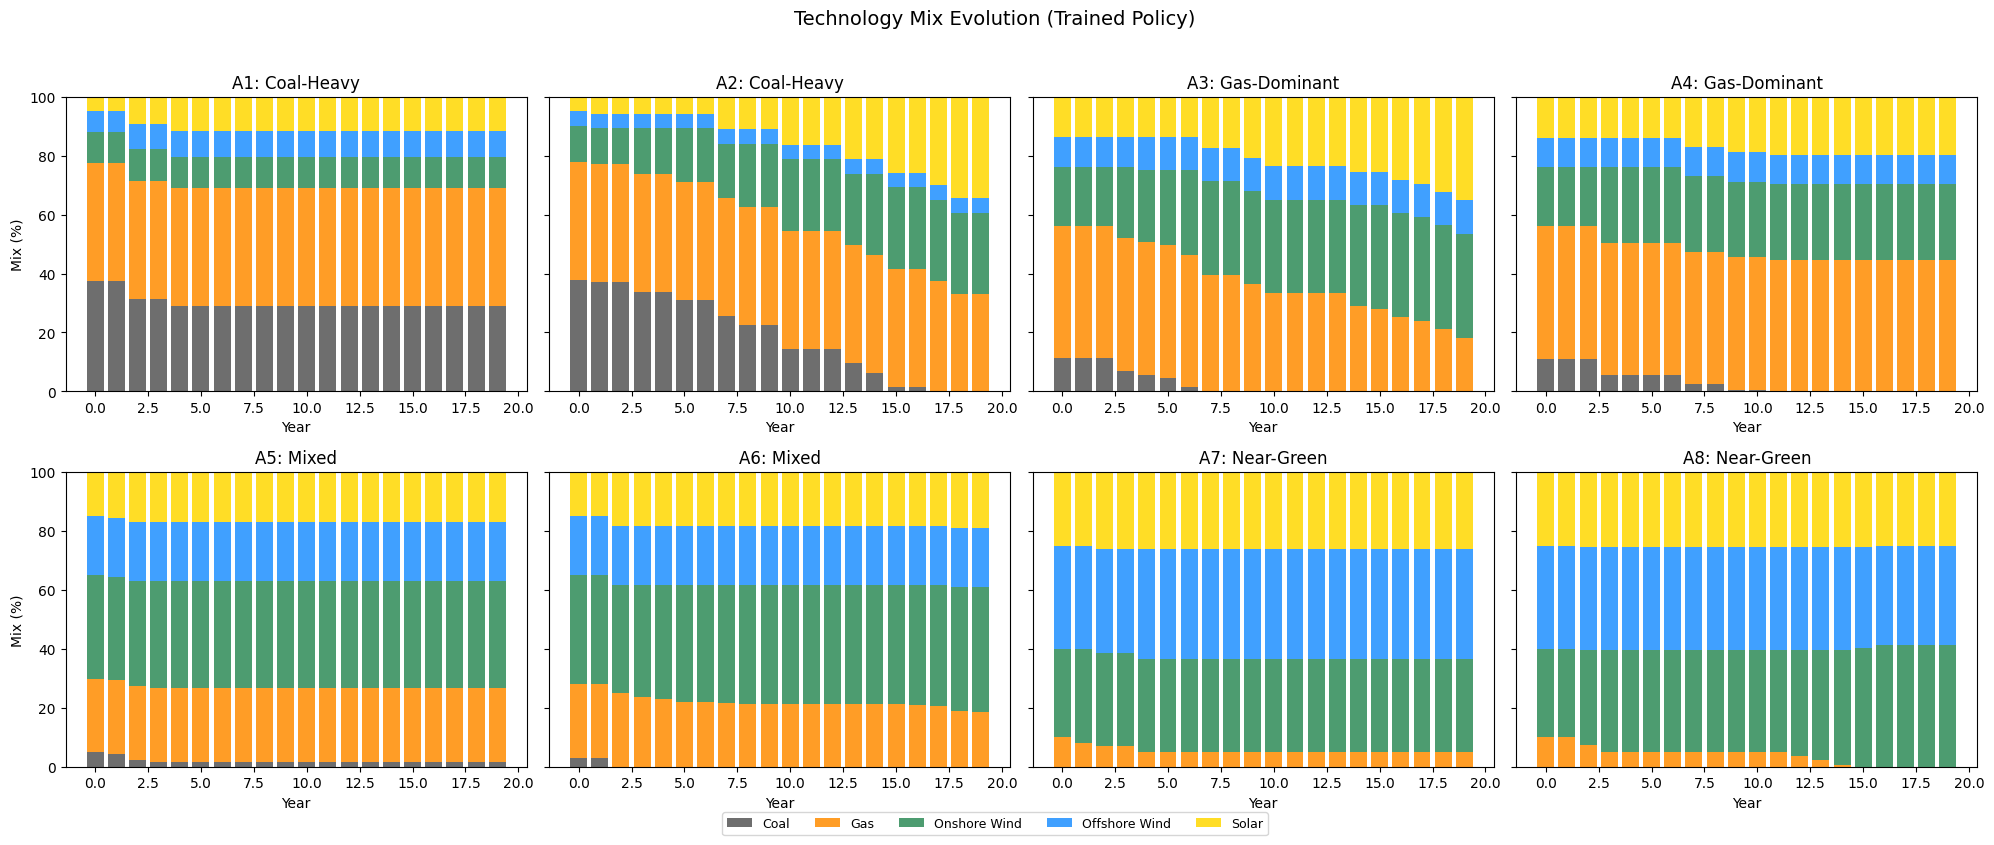

In [15]:
# Technology mix evolution per agent
tech_names = config['technologies']['names']
colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
          'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# Dynamic archetype labels (2 of each for 8 agents)
_base_archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']
archetypes = []
for arch in _base_archetypes:
    count = 0
    for mix in config['companies']['initial_mix']:
        # Match archetype by green fraction
        green = sum(mix[j] for j, g in enumerate(config['technologies']['is_green']) if g)
        if arch == 'Coal-Heavy' and green < 0.25:
            count += 1
        elif arch == 'Gas-Dominant' and 0.25 <= green < 0.55:
            count += 1
        elif arch == 'Mixed' and 0.55 <= green < 0.85:
            count += 1
        elif arch == 'Near-Green' and green >= 0.85:
            count += 1
# Simpler: just assign based on position
archetypes = []
n_per = n_agents // 4
for arch in _base_archetypes:
    for k in range(max(1, n_per)):
        archetypes.append(arch)
# Pad if needed
while len(archetypes) < n_agents:
    archetypes.append(f'Agent {len(archetypes)+1}')

ncols = min(4, n_agents)
nrows = (n_agents + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

for i in range(n_agents):
    ax = axes[i]
    bottom = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom,
               label=tech_names[t].replace('_', ' ').title(),
               color=colors[tech_names[t]], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Year')
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_title(f'A{i+1}: {archetypes[i]}')
    ax.set_ylim(0, 100)

# Hide unused axes
for j in range(n_agents, len(axes)):
    axes[j].set_visible(False)

# Single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Technology Mix Evolution (Trained Policy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Cost Sanity Check

Verify that investment costs match real-world data (action plan §2).

In [16]:
env = ETSEnvironment(config, seed=42)
env.reset()
c = env.companies[0]  # A1: coal-heavy

print('=== Investment Cost Sanity Check ===')
print(f'Company output: {c.output_twh} TWh/year = {c.output_mwh/1e6:.0f} million MWh')
print()

for tech_idx, name in [(2, 'Onshore Wind'), (3, 'Offshore Wind'), (4, 'Solar PV')]:
    frac = 0.03  # 3% of output
    delta_mwh = frac * c.output_mwh
    cf = c.capacity_factors[tech_idx]
    delta_mw = delta_mwh / (cf * 8760)
    cost = c.compute_investment_cost(tech_idx, frac)
    print(f'{name}:')
    print(f'  Shift: {frac*100:.0f}% = {delta_mwh/1e6:.0f} GWh/yr')
    print(f'  New capacity: {delta_mw:.0f} MW (at CF={cf:.0%})')
    print(f'  CapEx: {c.capex[tech_idx]:.0f} €/kW')
    print(f'  Investment cost: {cost:.1f} M€')
    print()

=== Investment Cost Sanity Check ===
Company output: 10.0 TWh/year = 10 million MWh

Onshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 98 MW (at CF=35%)
  CapEx: 1350 €/kW
  Investment cost: 132.7 M€

Offshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 73 MW (at CF=47%)
  CapEx: 3250 €/kW
  Investment cost: 237.7 M€

Solar PV:
  Shift: 3% = 0 GWh/yr
  New capacity: 201 MW (at CF=17%)
  CapEx: 750 €/kW
  Investment cost: 152.6 M€



## 9. Full Training Run (Longer)

Uncomment and run for a more complete training. Takes ~15-30 min on Colab GPU.

In [ ]:
# # Full training (uncomment to run)
from scripts.train import train_one_seed

full_config = config.copy()
full_config['simulation'] = dict(config['simulation'])
full_config['simulation']['n_episodes'] = 70000
full_config['logging'] = dict(config['logging'])
full_config['logging']['log_interval'] = 97
full_config['logging']['results_dir'] = 'results/'

train_one_seed(full_config, seed=42)


Training — seed 42, 8 agents, HAPPO (sequential update, centralized critic), two-phase
v5.0: MAC switching | Electricity revenue | Carry-forward | CF-cap=0.5×
Clipped Gaussian (no tanh) + P1-P8 active | Curriculum 4→20yr | ε-greedy 25%→5%

──────────────────────────────────────────────────────────────────────────────────
TRAINING CONSOLE — COLUMN GUIDE
──────────────────────────────────────────────────────────────────────────────────
Market header  (printed every log_interval episodes)
  price X→Y (peak Z) : ETS clearing price yr-0 → yr-N and peak  (€/t)
  cap                : Cap (Mt) in the final year
  TNAC               : Total allowances in circulation, final year
  sec_price/vol/match: Secondary market stats
  entropy/shaping    : PPO entropy coef & green-shaping weight
  [ENT-DECAY]        : Entropy decay triggered
  [cyc=Ax]           : Active agent (soft cycling)

Per-agent columns
  Green(0→N)  : Green fraction trajectory
  ΔGreen      : Net green change (pp)
  AvgEmiss    :